# Etude 1 : Winequality
## Prédiction de la qualité des vins en fonctions de leurs caractéristiques sur 11 variables chimiques

In [1]:
# Imports et fonctions utiles
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from keras import layers
from pathlib import Path
from keras import layers
import os, pickle

MODEL_FOLDER ="../models"
RESULT_FOLDER ="../results"

Path(MODEL_FOLDER).mkdir(parents=True, exist_ok=True)
Path(RESULT_FOLDER).mkdir(parents=True, exist_ok=True)

def show_data_img(X, n=200, shape=(28,28), dpi=100):
    plt.figure(figsize=(7.195, 3.841), dpi=dpi)
    nl = n // 20
    if n%20!=0: nl += 1
    
    for i in range(n):
        plt.subplot(nl,20,i+1)
        plt.imshow(X[i,:].reshape(shape), cmap='gray')
        plt.axis('off')
    plt.plot()
    
def show_errors_img(X, Y_pred, Y_true, shape=(28,28), dpi=100):
    plt.figure(figsize=(7.195, 3.841), dpi=dpi)
    n = min(len(X), len(Y_pred), len(Y_true), 30) # 30 erreurs au maximum
    X, Y_pred, Y_true = X[:n], Y_pred[:n], Y_true[:n]
    nl = n // 10
    if n%10!=0: nl += 1
    
    for i in range(n):
        plt.subplot(nl,10,i+1)
        x, yp, yt = X[i], Y_pred[i], Y_true[i]
        plt.imshow(x.reshape(shape), cmap='gray')
        plt.axis('off')
        plt.title(str(yp)+' ('+str(yt)+')')
    plt.plot()
    
def show_model_errors(model, X, y):
    proba = model.predict(X)
    y_pred = proba.argmax(axis=1)

    errors = [i for i in range(len(y_pred)) if y_pred[i]!=y[i]]
    show_errors_img(X[errors], y_pred[errors], y[errors])

### Fonction pour que les graphiques soit plus propres

In [2]:
def plot_metrics(mae, loss):
    models = list(dict.fromkeys(
        k.replace('_train', '').replace('_test', '') 
        for k in mae.keys()
    ))
    
    palette = plt.cm.tab10.colors
    color_map = {model: palette[i % len(palette)] for i, model in enumerate(models)}
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
    for key, values in mae.items():
        is_train = '_train' in key
        model = key.replace('_train', '').replace('_test', '')
        ax1.plot(values,
                 label=key,
                 color=color_map[model],
                 linewidth=2 if is_train else 1.2,
                 linestyle='--' if is_train else '-')
    ax1.set_title("Evolution de l'erreur absolue moyenne au cours de l'entrainement")
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    for key, values in loss.items():
        is_train = '_train' in key
        model = key.replace('_train', '').replace('_test', '')
        ax2.plot(values,
                 label=key,
                 color=color_map[model],
                 linewidth=2 if is_train else 1.2,
                 linestyle='--' if is_train else '-')
    ax2.set_title("Evolution de la loss au cours de l'entrainement")
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_loss(loss):
    models = list(dict.fromkeys(
        k.replace('_train', '').replace('_test', '') 
        for k in loss.keys()
    ))
    
    # Même palette que plot_metrics pour garder les couleurs cohérentes
    palette = plt.cm.tab10.colors
    color_map = {model: palette[i % len(palette)] for i, model in enumerate(models)}
    
    fig, ax = plt.subplots(figsize=(8, 5))
    
    for key, values in loss.items():
        if '_test' in key:
            model = key.replace('_test', '')
            ax.plot(values,
                    label=key,
                    color=color_map[model],
                    linewidth=1.2,
                    linestyle='-')
    
    ax.set_title("Evolution de la loss au cours de l'entrainement")
    ax.legend()
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def plot_mae(mae):
    models = list(dict.fromkeys(
        k.replace('_train', '').replace('_test', '') 
        for k in mae.keys()
    ))
    
    # Même palette que plot_metrics pour garder les couleurs cohérentes
    palette = plt.cm.tab10.colors
    color_map = {model: palette[i % len(palette)] for i, model in enumerate(models)}
    
    fig, ax = plt.subplots(figsize=(8, 5))
    
    for key, values in mae.items():
        if '_test' in key:
            model = key.replace('_test', '')
            ax.plot(values,
                    label=key,
                    color=color_map[model],
                    linewidth=1.2,
                    linestyle='-')
    
    ax.set_title("Evolution de l'erreur absolue moyenne au cours de l'entrainement")
    ax.legend()
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()


### Ce premier dataset répertorie les données de différents vins blanc, constituer de 12 variables, notre but sera de prédire la qualité des vins, une variable qualitatif de score entre 0 et 10, à partir des 11 variables suivantes :
1 - fixed acidity
<br>2 - volatile acidity
<br>3 - citric acid
<br>4 - residual sugar
<br>5 - chlorides
<br>6 - free sulfur dioxide
<br>7 - total sulfur dioxide
<br>8 - density
<br>9 - pH
<br>10 - sulphates
<br>11 - alcohol

#### Chargements des données de vins blanc et affichage des première ligne pour comprendre les données du dataset

In [3]:
winequality = pd.read_csv('../data/winequality-white.csv', sep=';')
print(winequality.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.0              0.27         0.36            20.7      0.045   
1            6.3              0.30         0.34             1.6      0.049   
2            8.1              0.28         0.40             6.9      0.050   
3            7.2              0.23         0.32             8.5      0.058   
4            7.2              0.23         0.32             8.5      0.058   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 45.0                 170.0   1.0010  3.00       0.45   
1                 14.0                 132.0   0.9940  3.30       0.49   
2                 30.0                  97.0   0.9951  3.26       0.44   
3                 47.0                 186.0   0.9956  3.19       0.40   
4                 47.0                 186.0   0.9956  3.19       0.40   

   alcohol  quality  
0      8.8        6  
1      9.5        6  
2     10.1        6 

#### Taille du dataset : on a donc 4898 lignes et 12 colonnes

In [4]:
print("Taille de l'ensemble de données :", winequality.shape)

Taille de l'ensemble de données : (4898, 12)


#### Quelle forme ont les entrées ? Quelles caractéristiques possèdent chaque donnée d'entrée ?


In [5]:
print("Caractéristiques des données d'entrée :", winequality.columns[:-1].tolist())
print(winequality.iloc[:, :-1].describe())

Caractéristiques des données d'entrée : ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    4898.000000       4898.000000  4898.000000     4898.000000   
mean        6.854788          0.278241     0.334192        6.391415   
std         0.843868          0.100795     0.121020        5.072058   
min         3.800000          0.080000     0.000000        0.600000   
25%         6.300000          0.210000     0.270000        1.700000   
50%         6.800000          0.260000     0.320000        5.200000   
75%         7.300000          0.320000     0.390000        9.900000   
max        14.200000          1.100000     1.660000       65.800000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  4898.000000          4898.000000           4898.000000  4898.00

#### Quelle forme ont les sorties ? Quelle est le sens de ces données ?

Caractéristiques des données de sortie : quality
Valeurs de la qualité du vin : quality
6    2198
5    1457
7     880
8     175
4     163
3      20
9       5
Name: count, dtype: int64


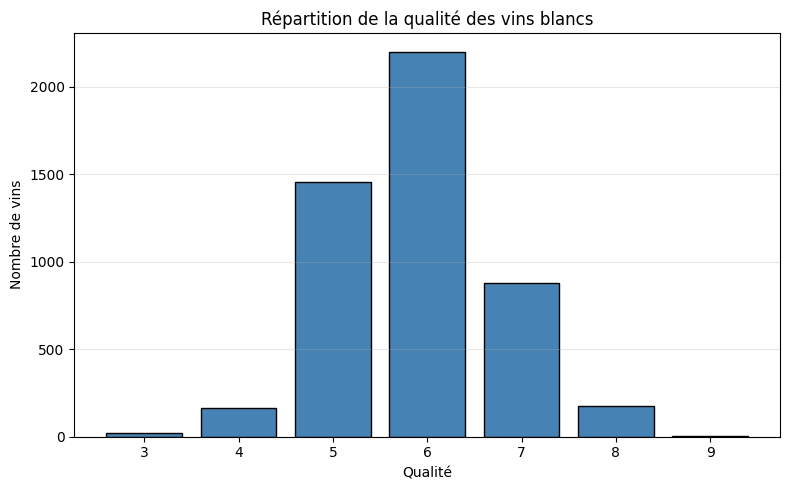

In [6]:
# C'est la qualité du vin, évaluée sur une échelle de 0 à 10 en valeur entière, où 0 est la pire qualité et 10 la meilleure. 
# Dans ce jeu de donnée on constate que les valeurs de qualité varient de 3 à 9. 
print("Caractéristiques des données de sortie :", winequality.columns[-1])
print("Valeurs de la qualité du vin :", winequality['quality'].value_counts())
plt.figure(figsize=(8, 5))
plt.bar(winequality['quality'].value_counts().sort_index().index, 
        winequality['quality'].value_counts().sort_index().values,
        color='steelblue', edgecolor='black')

plt.title("Répartition de la qualité des vins blancs")
plt.xlabel("Qualité")
plt.ylabel("Nombre de vins")
plt.xticks(winequality['quality'].unique())
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#### On comprend que le but de notre analyse est de prédire la qualité d'un vin selon la valeurs de ses 11 colonnes caractéristiques
#### Pour cela, nous allons utiliser plusieurs modèles de "Percetron multi-couches" qui permettrons de prédire la qualité des vins sur une partie du dataset

### 2. Préparation des données 
#### Séparer les données en deux ensembles : entraînement et test en 80/20

In [7]:
from sklearn.model_selection import train_test_split
X = winequality.drop('quality', axis=1).values
y = winequality['quality'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
print(X_train[:1])
print(y_train[:1])

[[7.3000e+00 1.7000e-01 3.6000e-01 8.2000e+00 2.8000e-02 4.4000e+01
  1.1100e+02 9.9272e-01 3.1400e+00 4.1000e-01 1.2400e+01]]
[6]


#### Normaliser les données d'entrées


In [9]:
X_train = (X_train - X_train.min(axis=0)) / (X_train.max(axis=0) - X_train.min(axis=0))
X_test = (X_test - X_test.min(axis=0)) / (X_test.max(axis=0) - X_test.min(axis=0))

## 3. Construction d'un modèle baseline 
#### Moyen de stockage de nos résultats des différents modèles


In [10]:
mae = {}
loss = {}

#### Préparation d'un modèle MLP qui servira de base de référence pour comparer les modèles. 

In [11]:
def baseline():
    m = keras.models.Sequential()
    m.add(keras.layers.Input(shape=(11,)))
    # m.add(keras.layers.Flatten()) # Inutile 
    m.add(keras.layers.Dense(32, activation='relu'))
    m.add(keras.layers.Dense(1))

    m.compile(optimizer=keras.optimizers.SGD(learning_rate=0.001), loss='mean_squared_error', metrics=['mae'])
    return m, "baseline"

def avance(couche1=64,couche2=32,dropout=False,dropout_rate=0.2):
    m = keras.models.Sequential()
    m.add(keras.layers.Input(shape=(11,)))
    # m.add(keras.layers.Flatten()) # Inutile 
    m.add(keras.layers.Dense(couche1, activation='relu'))
    if dropout : 
        m.add(keras.layers.Dropout(dropout_rate))
    m.add(keras.layers.Dense(couche2, activation='relu'))
    if dropout : 
        m.add(keras.layers.Dropout(dropout_rate))
    m.add(keras.layers.Dense(1))

    m.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mean_squared_error', metrics=['mae'])
    return m, f"MLP_{couche1}+{couche2}_{'dropout' if dropout else 'no_dropout'}"

#### Lancements des modèles créer et stockages des résultats dans le dossier /results et /models

In [12]:
%%capture
models = [baseline, avance, lambda: avance(), lambda: avance(32, 16, True)]

taille_batch = 32
nb_iterations = 50

for model_func in models:
    model, nom = model_func()
    print(f"\n=== Entrainement de {nom} ===")
    model.summary()
    
    s = model.fit(X_train, y_train, batch_size=taille_batch, epochs=nb_iterations, verbose=1, validation_data=(X_test, y_test))
    
    mae[nom+"_train"] = s.history['mae']
    mae[nom+"_test"] = s.history['val_mae']
    
    loss[nom+"_train"] = s.history['loss']
    loss[nom+"_test"] = s.history['val_loss']
    
    model.save(MODEL_FOLDER+"/WINE_"+nom+".keras")
    print(f"{nom} sauvegardé")

    with open(RESULT_FOLDER+"/WINE_mae_"+nom+".pickle", "wb") as f:
        pickle.dump({"train": s.history['mae'], "val": s.history['val_mae']}, f)
    
    with open(RESULT_FOLDER+"/WINE_loss_"+nom+".pickle", "wb") as f:
        pickle.dump({"train": s.history['loss'], "val": s.history['val_loss']}, f)

#### Visualisation de la qualité des modèles

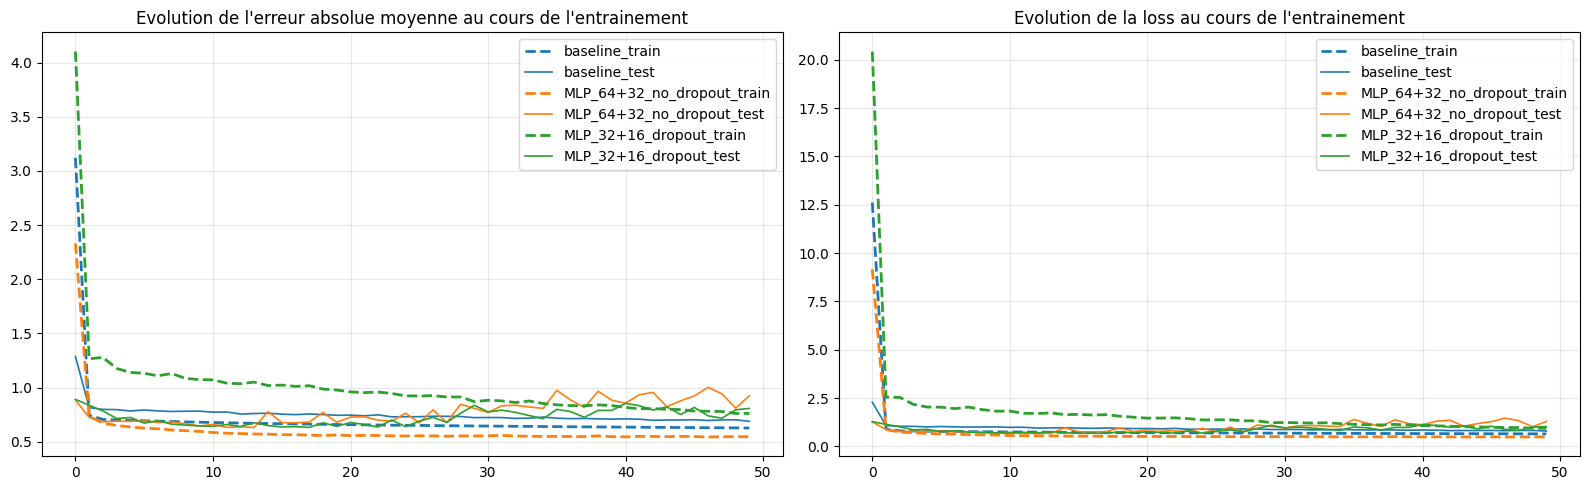

In [13]:
plot_metrics(mae, loss)

#### Nous avons constaté qu'il y avait du sur-apprentissage sur certains modèles, alors nous allons utiliser l'EarlyStopping avec une valeur de patience de 10 afin de ne pas faire d'entrainement pour rien, voir pire car le modèle MLP_64+32_no_dropout diverge, on constate une réaugementation de son MAE qui est forte

In [14]:
%%capture
models = [baseline, avance, lambda: avance(), lambda: avance(32, 16, True)]

taille_batch = 32
nb_iterations = 50

for model_func in models:
    model, nom = model_func()
    print(f"\n=== Entrainement de {nom} ===")
    model.summary()
    
    s = model.fit(X_train, y_train, batch_size=taille_batch, epochs=nb_iterations, verbose=1, validation_data=(X_test, y_test),callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)])
    
    mae[nom+"_train"] = s.history['mae']
    mae[nom+"_test"] = s.history['val_mae']
    
    loss[nom+"_train"] = s.history['loss']
    loss[nom+"_test"] = s.history['val_loss']
    
    model.save(MODEL_FOLDER+"/WINE_"+nom+".keras")
    print(f"{nom} sauvegardé")

    with open(RESULT_FOLDER+"/WINE_mae_"+nom+".pickle", "wb") as f:
        pickle.dump({"train": s.history['mae'], "val": s.history['val_mae']}, f)
    
    with open(RESULT_FOLDER+"/WINE_loss_"+nom+".pickle", "wb") as f:
        pickle.dump({"train": s.history['loss'], "val": s.history['val_loss']}, f)

#### Graphiques avec EarlyStopping et pour analyser les résultats sur les données de test

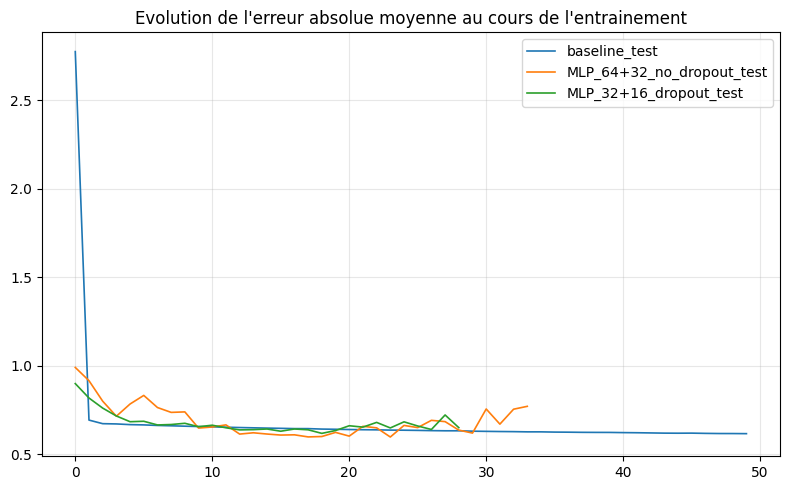

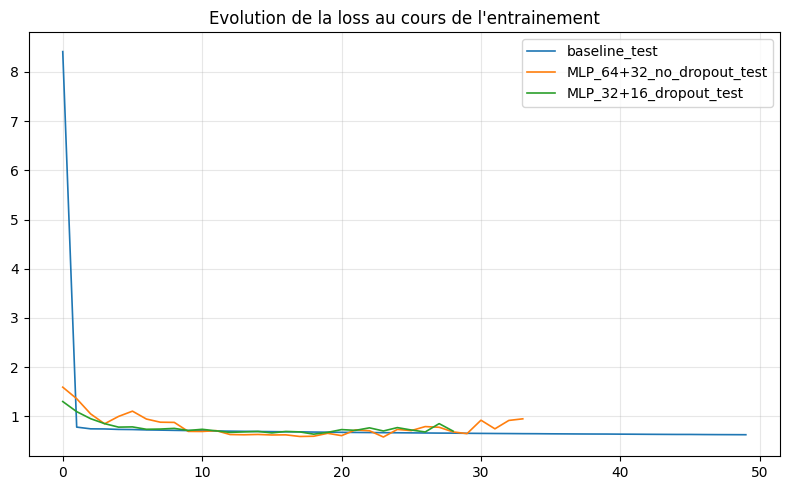

In [15]:
plot_mae(mae)
plot_loss(loss)

#### Recharger le modèle qui est le plus utile pour notre analyse pour ses résultats

In [16]:
from keras.models import load_model 
meilleur_model = load_model(MODEL_FOLDER+"/WINE_baseline.keras")

In [17]:
score = meilleur_model.evaluate(X_test,y_test , batch_size = 64, verbose =1)
score

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6253 - mae: 0.6170 


[0.6253176331520081, 0.6169630289077759]

#### Visualisation des erreurs de prédictions

Text(0, 0.5, 'Fréquence')

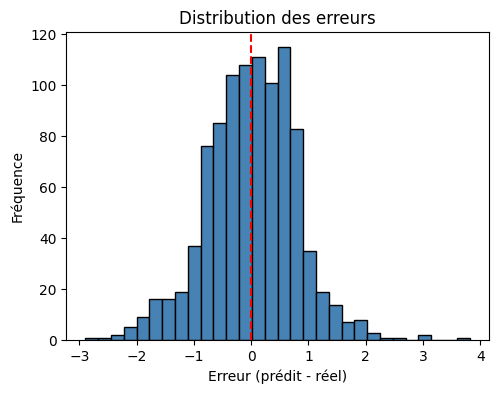

In [18]:
y_pred = meilleur_model.predict(X_test, verbose=0).flatten()
erreurs = y_pred - y_test

plt.figure(figsize=(12, 4))

# Histogramme des erreurs
plt.subplot(1, 2,1)
plt.hist(erreurs, bins=30, color='steelblue', edgecolor='black')
plt.axvline(0, color='red', linestyle='--')
plt.title("Distribution des erreurs")
plt.xlabel("Erreur (prédit - réel)")
plt.ylabel("Fréquence")




In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
dans_1_note = np.mean(abs(erreurs) <= 1) * 100

print(f"Erreur Absolue Moyenne           : {mae:.4f}")
print(f"Erreur Quadratique Moyenne       : {rmse:.4f}")
print(f"Prédictions à + ou - 1 note près : {dans_1_note:.1f}%")
print(f"Erreur maximum                   : {abs(erreurs).max():.4f}")
print(f"Erreur moyenne                   : {np.mean(abs(erreurs)):.4f}")

Erreur Absolue Moyenne           : 0.6170
Erreur Quadratique Moyenne       : 0.7908
Prédictions à + ou - 1 note près : 83.7%
Erreur maximum                   : 3.8141
Erreur moyenne                   : 0.6170
